## PROYECTO FINAL - Clasificación de pacientes con esquizofrenia

Alumnos: Ricardo Amiel y Josué Jeremias

## Estado del pipeline
*(este bloque se actualiza en cada iteración para saber siempre en qué fase estamos)*

**Fase 1 — Preprocesamiento EEG**
- [x] Carga de metadatos y mapeo binario de diagnóstico (sano=0 / esquizofrenia=1)
- [x] Función de preprocesamiento por archivo (filtros 0.5–45 Hz, notch 50 Hz, resample 250 Hz, ventanas 5 s, z-score)
- [x] Armonización de canales por nombre entre los dos formatos de adquisición del dataset (fix aplicado — **pendiente confirmar resultado de la re-ejecución**)
- [ ] Split train / val / test a nivel de sujeto (sin fuga de información)
- [ ] Verificación final de balance de clases tras el split

**Fase 2 — Transformación a imágenes tiempo-frecuencia**
- [x] Espectrogramas STFT (función probada, corre correctamente)
- [~] Escalogramas Wavelet: implementados pero **descartados por decisión** (cuello de botella de rendimiento); se prioriza FFT/STFT
- [ ] Generación del banco de imágenes ya sobre los conjuntos train/val/test separados por sujeto

**Fase 3 — Extracción y selección de características clásicas**
- [ ] Extracción de características con `tsfresh`
- [ ] Selección de características (reducción de dimensionalidad)

**Fase 4 — Entrenamiento de modelos**
- [ ] Modelos clásicos: SVM, XGBoost, Random Forest, Regresión logística
- [ ] Modelos DL: CNN propia + ResNet/EfficientNet (transfer learning)
- [ ] (Opcional, si alcanza el tiempo) ViT/Swin o EEG-Conformer

**Fase 5 — Comparación experimental final**
- [ ] Métricas: accuracy, precision, recall, specificity, F1, ROC-AUC, balanced accuracy, matriz de confusión
- [ ] Tabla comparativa clásico vs. deep learning
- [ ] Conclusiones

Leyenda: `[x]` completado · `[~]` completado pero descartado/cambiado de plan · `[ ]` pendiente

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import mne
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# =====================================================================
# 1. PARÁMETROS GENERALES DE PREPROCESAMIENTO CLÍNICO
# =====================================================================
BASE_DATASET_DIR = "./ASZED-153"
CSV_PATH = os.path.join(BASE_DATASET_DIR, "ASZED_SpreadSheet.csv")

FREQ_LOW = 0.5       # Filtro pasa-alta (remueve deriva lenta de los electrodos)
FREQ_HIGH = 45.0     # Filtro pasa-baja (remueve interferencia electromuscular de alta frecuencia)
FREQ_NOTCH = 50.0    # Filtro Notch (remueve el ruido de la línea eléctrica ambiental)
WINDOW_SEC = 5.0     # Tamaño de cada ventana temporal de EEG en segundos
TARGET_SFREQ = 250.0

# [FIX] El dataset ASZED tiene DOS formatos de adquisición distintos:
#   Formato A: 'EEG Fp1-LE', 'EEG C3-LE', ... (20 canales, incluye referencia A2, 256 Hz)
#   Formato B: 'Fp1[1]', 'C3[5]', ... (24 canales, incluye EMG/EOG/Pg1/Pg2, 200-100 Hz)
# Ambos comparten el mismo set de 19 electrodos estándar 10-20. Armonizamos por NOMBRE
# (no por conteo de canales) para no perder ningún sujeto de ninguna clase.
CANONICAL_CHANNELS = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
                       'T3', 'C3', 'Cz', 'C4', 'T4',
                       'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']

def normalize_channel_name(name):
    """Normaliza nombres de canal de ambos formatos de adquisición a la
    convención estándar 10-20: quita prefijo 'EEG ', sufijo '-LE' y
    sufijo numérico '[n]'."""
    n = name.strip()
    n = re.sub(r'^EEG\s+', '', n, flags=re.IGNORECASE)
    n = re.sub(r'-LE$', '', n, flags=re.IGNORECASE)
    n = re.sub(r'\[\d+\]$', '', n)
    return n

print("Librerías cargadas. Configurando pipeline...")


Librerías cargadas. Configurando pipeline...


## Preprocesamiento EEG


### Fase 1. Carga y organización de los registros por sujeto, clase y paradigma experimental.

In [2]:
# =====================================================================
# 2. CARGA Y TRADUCCIÓN BINARIA DE METADATOS
# =====================================================================
mapping_dict = {}

try:
    df_meta = pd.read_csv(CSV_PATH)
    df_meta.columns = df_meta.columns.str.strip()
    df_meta['sn_clean'] = df_meta['sn'].astype(str).str.strip().str.lower()
    df_meta['category_clean'] = df_meta['category'].astype(str).str.strip().str.lower()
    
    # Mapeo binario: 'patient' -> 1 (Esquizofrenia), 'control' -> 0 (Sano)
    df_meta['Diagnosis'] = df_meta['category_clean'].apply(lambda x: 1 if 'patient' in x else 0)
    mapping_dict = dict(zip(df_meta['sn_clean'], df_meta['Diagnosis']))
    
    print(f"[✓] SpreadSheet mapeada con éxito.")
    print(f"    -> Total de sujetos registrados en el CSV maestro: {len(mapping_dict)}")
except Exception as e:
    print(f"[!] Error crítico procesando el archivo CSV: {e}")

[✓] SpreadSheet mapeada con éxito.
    -> Total de sujetos registrados en el CSV maestro: 153


In [3]:
df_meta

,sn,age,gender,category,language,node,sn_clean,category_clean,Diagnosis
0,subject_2,50,F,Patient,Yoruba,OAUTHC_IFE_ILESA,subject_2,patient,1
1,subject_3,45,F,Patient,English,OAUTHC_IFE_ILESA,subject_3,patient,1
2,subject_4,35,M,Patient,English,OAUTHC_IFE_ILESA,subject_4,patient,1
3,subject_5,28,M,Patient,English,OAUTHC_IFE_ILESA,subject_5,patient,1
4,subject_6,39,F,Patient,English,OAUTHC_IFE_ILESA,subject_6,patient,1
...,...,...,...,...,...,...,...,...,...
148,subject_156,44,M,Control,English,OAUTHC_IFE_ILESA,subject_156,control,0
149,subject_157,30,F,Control,English,OAUTHC_IFE_ILESA,subject_157,control,0
150,subject_158,51,M,Control,Yoruba,OAUTHC_IFE_ILESA,subject_158,control,0
151,subject_159,33,F,Control,English,OAUTHC_IFE_ILESA,subject_159,control,0


In [4]:
# =====================================================================
# 3. FUNCIÓN DE PREPROCESAMIENTO CLÍNICO POR ARCHIVO (con armonización de canales)
# =====================================================================
def preprocess_edf_file(edf_path, freq_low, freq_high, freq_notch, window_sec, target_sfreq=250.0):
    """
    Carga señales .edf, ARMONIZA los canales al estándar 10-20 de 19 canales
    (sin importar el formato de adquisición original), remuestrea a frecuencia
    estándar, filtra ruidos y segmenta aplicando normalización Z-score.

    Retorna (windows, sfreq, reason). 'reason' es None si todo salió bien,
    o un string explicando por qué se descartó el archivo.
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

        # [FIX] Armonización de nombres de canal entre los dos formatos del dataset
        rename_map = {}
        for ch in raw.ch_names:
            norm = normalize_channel_name(ch)
            for canon in CANONICAL_CHANNELS:
                if norm.lower() == canon.lower():
                    rename_map[ch] = canon
                    break
        raw.rename_channels(rename_map)

        available = [c for c in CANONICAL_CHANNELS if c in raw.ch_names]
        if len(available) < len(CANONICAL_CHANNELS):
            missing = sorted(set(CANONICAL_CHANNELS) - set(available))
            return None, None, f"faltan canales: {missing}"

        # Selecciona EXACTAMENTE los 19 canales estándar, siempre en el mismo orden
        # (descarta de paso EMG/EOG/Pg1/Pg2/A2, que no son señal cortical comparable)
        raw.pick_channels(CANONICAL_CHANNELS, ordered=True)

        if raw.info['sfreq'] != target_sfreq:
            raw.resample(sfreq=target_sfreq, verbose=False)

        raw.filter(l_freq=freq_low, h_freq=freq_high, fir_design='firwin', verbose=False)
        raw.notch_filter(freqs=freq_notch, fir_design='firwin', verbose=False)

        data, times = raw.get_data(return_times=True)
        sfreq = raw.info['sfreq']

        samples_per_window = int(window_sec * sfreq)
        total_samples = data.shape[1]
        num_windows = total_samples // samples_per_window

        if num_windows == 0:
            return None, None, f"registro muy corto ({total_samples} muestras)"

        file_windows = []
        for w in range(num_windows):
            start_idx = w * samples_per_window
            end_idx = start_idx + samples_per_window
            window_data = data[:, start_idx:end_idx]

            # Normalización Z-score por canal
            mean = np.mean(window_data, axis=1, keepdims=True)
            std = np.std(window_data, axis=1, keepdims=True) + 1e-8
            normalized_window = (window_data - mean) / std

            file_windows.append(normalized_window)

        return np.array(file_windows), sfreq, None
    except Exception as e:
        return None, None, f"excepción: {e}"


In [5]:
# =====================================================================
# 4. EXTRACCIÓN Y PROCESAMIENTO RECURSIVO (con canales ya armonizados)
# =====================================================================
from collections import Counter

all_windows = []
all_labels = []
all_subjects = []

# Escaneo dinámico recursivo agnóstico a las carpetas intermedias
subject_folders = glob.glob(os.path.join(BASE_DATASET_DIR, "**", "subject_*"), recursive=True) + \
                  glob.glob(os.path.join(BASE_DATASET_DIR, "**", "Subject_*"), recursive=True)
subject_folders = sorted(list(set(subject_folders)))

print("\n[*] Iniciando carga masiva y procesamiento digital de señales...")

discard_reasons = Counter()
processed_files = 0
expected_shape = (len(CANONICAL_CHANNELS), int(WINDOW_SEC * TARGET_SFREQ))

for sub_folder in subject_folders:
    folder_name = os.path.basename(sub_folder.rstrip(os.sep)).strip().lower()
    label = mapping_dict.get(folder_name, None)

    if label is None:
        continue

    edf_files = glob.glob(os.path.join(sub_folder, "**", "*.edf"), recursive=True) + \
                glob.glob(os.path.join(sub_folder, "**", "*.EDF"), recursive=True)
    edf_files = sorted(list(set(edf_files)))

    try:
        sub_id_int = int(folder_name.split("_")[-1])
    except ValueError:
        sub_id_int = 999

    for edf_path in edf_files:
        processed_files += 1
        windows, sfreq, reason = preprocess_edf_file(edf_path, FREQ_LOW, FREQ_HIGH, FREQ_NOTCH, WINDOW_SEC, TARGET_SFREQ)

        if windows is None:
            discard_reasons[reason] += 1
            continue

        for window in windows:
            # Verificación defensiva: con la armonización de canales esto SIEMPRE debe cumplirse
            assert window.shape == expected_shape, f"Forma inesperada {window.shape} en {edf_path}"
            all_windows.append(window)
            all_labels.append(label)
            all_subjects.append(sub_id_int)

print(f"[INFO] Archivos .edf procesados: {processed_files}")
if discard_reasons:
    print("[INFO] Archivos descartados por motivo:")
    for reason, count in discard_reasons.most_common():
        print(f"   - {reason}: {count}")
else:
    print("[INFO] Ningún archivo descartado.")



[*] Iniciando carga masiva y procesamiento digital de señales...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code s

In [6]:
# =====================================================================
# 5. CONSOLIDACIÓN DE MATRICES TRIDIMENSIONALES DE ENTRADA
# =====================================================================
print("\n" + "=" * 60)
print("             FASE 1 COMPLETADA: RESUMEN DE MATRICES             ")
print("=" * 60)

if len(all_windows) > 0:
    X = np.array(all_windows)
    y = np.array(all_labels)
    groups = np.array(all_subjects)

    print(f"[✓] Matriz X consolidada (Ventanas, Canales, Muestras): {X.shape}")
    print(f"[✓] Vector y consolidado (Etiquetas Binarias):           {y.shape}")
    print(f"    - Ventanas Totales de Controles Sanos (Clase 0): {np.sum(y == 0)}")
    print(f"    - Ventanas Totales de Pacientes (Clase 1):      {np.sum(y == 1)}")
    print(f"    - Total de sujetos únicos integrados al pipeline: {len(np.unique(groups))}")

    # [FIX] Verificación clave: ¿sobreviven sujetos de ambas clases en proporción razonable?
    df_check = pd.DataFrame({'subject': groups, 'label': y})
    print(f"    - Sujetos únicos por clase (0=control, 1=paciente):")
    print(df_check.groupby('label')['subject'].nunique().to_string())
else:
    print("[!] Error crítico en el pipeline: No se pudo consolidar ninguna ventana numérica.")



             FASE 1 COMPLETADA: RESUMEN DE MATRICES             


[✓] Matriz X consolidada (Ventanas, Canales, Muestras): (5946, 19, 1250)
[✓] Vector y consolidado (Etiquetas Binarias):           (5946,)
    - Ventanas Totales de Controles Sanos (Clase 0): 2946
    - Ventanas Totales de Pacientes (Clase 1):      3000
    - Total de sujetos únicos integrados al pipeline: 153
    - Sujetos únicos por clase (0=control, 1=paciente):
label
0    77
1    76


### Diagnóstico previo: ¿por qué se descartan tantas ventanas/sujetos?

Antes de seguir con el pipeline, inspeccionamos los `.edf` **sin cargar las señales completas** (solo headers) para entender si el descarte masivo del Shape Guard (3102 ventanas descartadas) se debe a una diferencia real de canales entre sujetos, y si esto está afectando desproporcionadamente a una de las dos clases.

In [7]:
# =====================================================================
# DIAGNÓSTICO: inspección de headers .edf (sin preload) por sujeto
# =====================================================================
diag_rows = []

for sub_folder in subject_folders:
    folder_name = os.path.basename(sub_folder.rstrip(os.sep)).strip().lower()
    label = mapping_dict.get(folder_name, None)
    if label is None:
        continue

    edf_files = glob.glob(os.path.join(sub_folder, "**", "*.edf"), recursive=True) + \
                glob.glob(os.path.join(sub_folder, "**", "*.EDF"), recursive=True)
    edf_files = sorted(list(set(edf_files)))

    if len(edf_files) == 0:
        diag_rows.append({
            "subject": folder_name, "label": label, "file": None,
            "n_channels": None, "channel_names": None, "sfreq": None,
            "duration_sec": None, "error": "sin .edf encontrado"
        })
        continue

    for edf_path in edf_files:
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
            raw.pick_types(eeg=True, stim=False, exclude='bads', verbose=False)
            diag_rows.append({
                "subject": folder_name,
                "label": label,
                "file": os.path.basename(edf_path),
                "n_channels": len(raw.ch_names),
                "channel_names": tuple(sorted(raw.ch_names)),
                "sfreq": raw.info['sfreq'],
                "duration_sec": raw.n_times / raw.info['sfreq'],
                "error": None
            })
        except Exception as e:
            diag_rows.append({
                "subject": folder_name, "label": label, "file": os.path.basename(edf_path),
                "n_channels": None, "channel_names": None, "sfreq": None,
                "duration_sec": None, "error": str(e)
            })

df_diag = pd.DataFrame(diag_rows)
print(f"Total de archivos .edf inspeccionados: {len(df_diag)}")
print(f"Archivos con error de lectura: {df_diag['error'].notna().sum()}")


Total de archivos .edf inspeccionados: 1932
Archivos con error de lectura: 0


In [8]:
# =====================================================================
# DIAGNÓSTICO: distribución de canales / sfreq y supervivencia por clase
# =====================================================================
print("Distribución de número de canales EEG por archivo:")
print(df_diag['n_channels'].value_counts(dropna=False))
print()

print("Distribución de frecuencias de muestreo (sfreq):")
print(df_diag['sfreq'].value_counts(dropna=False))
print()

print("Sujetos únicos en el CSV maestro, por clase (0=control, 1=paciente):")
print(df_meta.groupby('Diagnosis')['sn_clean'].nunique())
print()

df_diag_ok = df_diag.dropna(subset=['n_channels'])
print("Sujetos únicos con al menos un .edf leíble, por clase:")
print(df_diag_ok.groupby('label')['subject'].nunique())
print()

most_common_n_channels = df_diag_ok['n_channels'].mode()[0]
print(f"Número de canales más frecuente (el que quedó como 'molde' = {most_common_n_channels}):")
matching = df_diag_ok[df_diag_ok['n_channels'] == most_common_n_channels]
not_matching = df_diag_ok[df_diag_ok['n_channels'] != most_common_n_channels]
print(f"  Archivos que SÍ calzan: {len(matching)}  -> sujetos únicos: {matching['subject'].nunique()}")
print(f"  Archivos que NO calzan: {len(not_matching)}  -> sujetos únicos: {not_matching['subject'].nunique()}")
print()

print("Sujetos únicos que SÍ calzan con el molde, por clase:")
print(matching.groupby('label')['subject'].nunique())
print()
print("Sujetos únicos que NO calzan con el molde, por clase:")
print(not_matching.groupby('label')['subject'].nunique())
print()

unique_channel_sets = df_diag_ok['channel_names'].value_counts()
print(f"Número de combinaciones distintas de NOMBRES de canal encontradas: {len(unique_channel_sets)}")
print(unique_channel_sets.head(10))


Distribución de número de canales EEG por archivo:
n_channels
20    1149
24     783
Name: count, dtype: int64

Distribución de frecuencias de muestreo (sfreq):
sfreq
256.0    1149
200.0     759
100.0      24
Name: count, dtype: int64

Sujetos únicos en el CSV maestro, por clase (0=control, 1=paciente):
Diagnosis
0    77
1    76
Name: sn_clean, dtype: int64

Sujetos únicos con al menos un .edf leíble, por clase:
label
0    77
1    76
Name: subject, dtype: int64

Número de canales más frecuente (el que quedó como 'molde' = 20):
  Archivos que SÍ calzan: 1149  -> sujetos únicos: 77
  Archivos que NO calzan: 783  -> sujetos únicos: 76

Sujetos únicos que SÍ calzan con el molde, por clase:
label
0    53
1    24
Name: subject, dtype: int64

Sujetos únicos que NO calzan con el molde, por clase:
label
0    24
1    52
Name: subject, dtype: int64

Número de combinaciones distintas de NOMBRES de canal encontradas: 2
channel_names
(EEG A2-LE, EEG C3-LE, EEG C4-LE, EEG Cz-LE, EEG F3-LE, EEG F4-LE, 

Note que, si intentamos obtener los datos sin una **frecuencia con cota superior** da error debido a que muchas señales se muestrean en distintas frecuencias. 

Algunos registros .edf pueden venir muestreados a 250 Hz, otros a 500 Hz o 1000 Hz. Al multiplicar duración×sfreq, un archivo genera ventanas de 1250 puntos de tiempo y otro genera 2500 o 5000 puntos.

Algunos archivos incluyen electrodos adicionales de referencia, canales de electrocardiograma (ECG), electrooculograma (EOG) o canales de anotación de eventos de la máquina, haciendo que un sujeto tenga 19 canales y otro tenga 20 o 22.

Al meter este bloque, las dimensiones de X se volverán homogéneas. Cuéntame qué forma (shape) te arroja la impresión final del reporte para saber con certeza que tus tensores están listos, aunque para ello tenemos que descartar ventanas con comportamientos anómalos.

### Fase 2. Selección inicial de una condición.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, welch  # STFT y Welch siguen estando en SciPy
import pywt                           # Nueva librería para Wavelets

# =====================================================================
# 1. PARÁMETROS DE LA CONFIGURACIÓN TIEMPO-FRECUENCIA
# =====================================================================
SFREQ = 250.0  # Frecuencia unificada de nuestro tensor X (250 Hz)

print("Matriz X detectada en memoria con forma:", X.shape)
print("Generando extractores de imágenes tiempo-frecuencia...")

Matriz X detectada en memoria con forma: (5946, 19, 1250)
Generando extractores de imágenes tiempo-frecuencia...


In [10]:
# =====================================================================
# 2. ENFOQUE A: GENERACIÓN DE ESPECTROGRAMAS (STFT)
# =====================================================================
def generate_stft_images(X_data, sfreq):
    """
    Transforma el tensor temporal X (Ventanas, Canales, Muestras) en un tensor
    de Espectrogramas 2D usando STFT de SciPy.
    """
    print("[*] Computando Espectrogramas STFT...")
    stft_list = []
    
    for i in range(len(X_data)):
        window_channels = X_data[i]  # Forma: (24, 1250)
        window_spectrograms = []
        
        for ch in range(window_channels.shape[0]):
            f, t_axis, Zxx = stft(window_channels[ch], fs=sfreq, nperseg=128, noverlap=64)
            magnitude = np.abs(Zxx)
            
            # Filtrar la banda de interés clínico de interés en Esquizofrenia (0.5 - 45 Hz)
            freq_mask = (f >= 0.5) & (f <= 45.0)
            magnitude_filtered = magnitude[freq_mask, :]
            window_spectrograms.append(magnitude_filtered)
            
        stft_list.append(np.array(window_spectrograms))
        
    return np.array(stft_list)

In [11]:
# =====================================================================
# 3. ENFOQUE B: GENERACIÓN DE ESCALOGRAMAS WAVELET ROBUSTOS (PyWavelets)
# =====================================================================
def generate_wavelet_images(X_data, sfreq):
    """
    Transforma el tensor temporal X en Escalogramas 2D usando pywt.cwt.
    Garantiza el mapeo exacto de las frecuencias analíticas (0.5 a 45 Hz).
    """
    print("[*] Computando Escalogramas Wavelet continuos mediante PyWavelets...")
    
    # Definimos las frecuencias lineales que representarán nuestro eje Y (40 filas verticales)
    frequencies = np.linspace(0.5, 45.0, num=40)
    
    # Seleccionamos la Wavelet de Morlet Compleja estándar en neurociencia: 'cmorB-C'
    # donde B es el ancho de banda (1.5) y C es la frecuencia central (1.0)
    wavelet_name = 'cmor1.5-1.0'
    
    # [NUEVO] Convertir las frecuencias físicas (Hz) a escalas matemáticas de PyWavelets
    # Nota: requiere frecuencias normalizadas dividiendo por sfreq
    scales = pywt.frequency2scale(wavelet_name, frequencies / sfreq)
    
    wavelet_list = []
    
    for i in range(len(X_data)):
        window_channels = X_data[i]
        window_escalograms = []
        
        for ch in range(window_channels.shape[0]):
            # pywt.cwt devuelve los coeficientes complejos y sus frecuencias asociadas
            coefs, freqs_computed = pywt.cwt(window_channels[ch], scales, wavelet_name, sampling_period=1.0/sfreq)
            
            # La magnitud absoluta representa la densidad de energía tiempo-frecuencia
            magnitude = np.abs(coefs)
            window_escalograms.append(magnitude)
            
        wavelet_list.append(np.array(window_escalograms))
        
    return np.array(wavelet_list)

In [12]:
# =====================================================================
# 4. CONVERSIÓN Y PROCESAMIENTO MULTICANAL DE LOS NUEVOS TENSORES
# =====================================================================
# Generamos los dos bancos de imágenes independientes para comparar arquitecturas profundas
X_stft = generate_stft_images(X, SFREQ)
#X_cwt = generate_wavelet_images(X, SFREQ)

print("\n" + "="*60)
print("             REPORTE FINAL DE GENERACIÓN DE IMÁGENES             ")
print("======================================================")
print(f"[✓] Tensor STFT listo: {X_stft.shape}  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)")
#print(f"[✓] Tensor CWT listo:  {X_cwt.shape}   | (Muestras, Canales, Frecuencias_Y, Tiempo_X)")
print("="*60)

[*] Computando Espectrogramas STFT...

             REPORTE FINAL DE GENERACIÓN DE IMÁGENES             
[✓] Tensor STFT listo: (5946, 19, 23, 21)  | (Muestras, Canales, Frecuencias_Y, Tiempo_X)


[✓] Gráfica de control de calidad visual exportada a 'muestras_tiempo_frecuencia_eeg.pdf'.


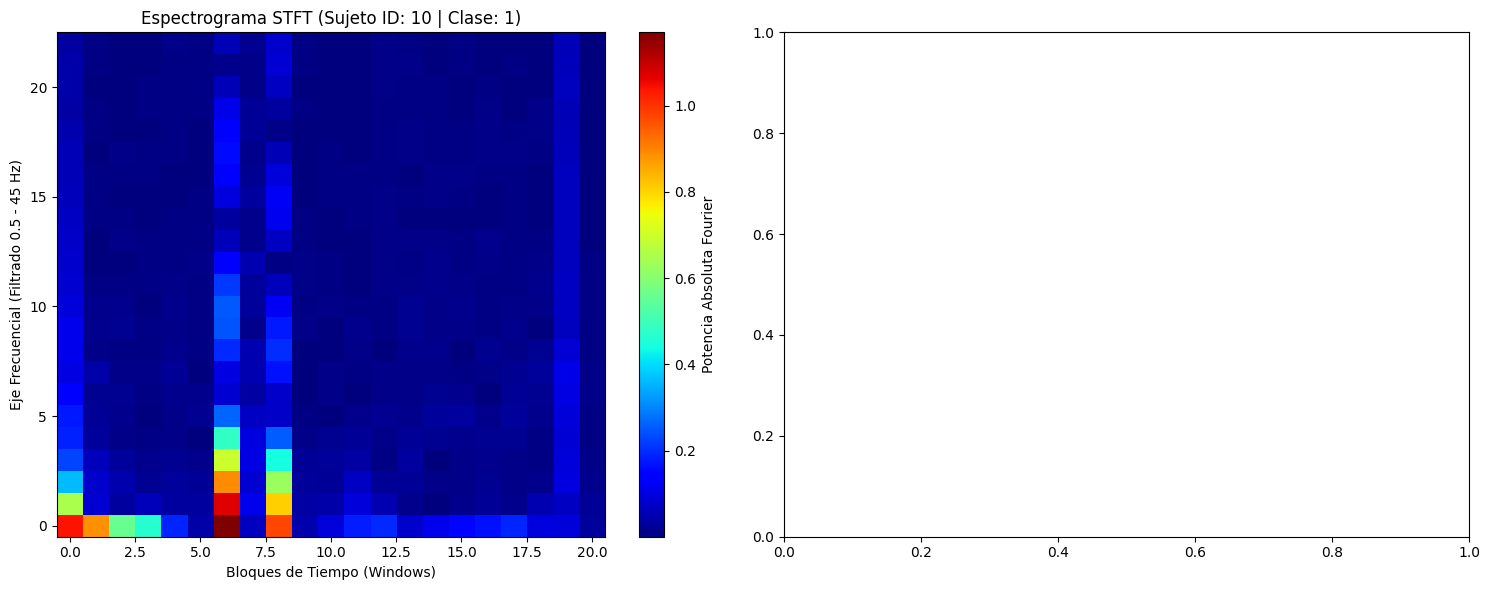

In [13]:
# =====================================================================
# 5. GENERACIÓN DE LA MUESTRA GRÁFICA (Guardado seguro en disco)
# =====================================================================
# Evaluamos visualmente el primer canal del primer paciente para el informe de Overleaf
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Graficar Espectrograma STFT
im0 = axs[0].imshow(X_stft[0, 0, :, :], aspect='auto', cmap='jet', origin='lower')
axs[0].set_title(f"Espectrograma STFT (Sujeto ID: {groups[0]} | Clase: {y[0]})")
axs[0].set_xlabel("Bloques de Tiempo (Windows)")
axs[0].set_ylabel("Eje Frecuencial (Filtrado 0.5 - 45 Hz)")
fig.colorbar(im0, ax=axs[0], label="Potencia Absoluta Fourier")

# Graficar Escalograma Wavelet (PyWavelets)
'''
im1 = axs[1].imshow(X_cwt[0, 0, :, :], aspect='auto', cmap='jet', origin='lower')
axs[1].set_title(f"Escalograma CWT PyWavelets (Sujeto ID: {groups[0]} | Clase: {y[0]})")
axs[1].set_xlabel("Muestras de Tiempo Continuas (Samples)")
axs[1].set_ylabel("Frecuencia Wavelet (0.5 - 45 Hz)")
fig.colorbar(im1, ax=axs[1], label="Magnitud de Coeficientes Morlet")
'''

plt.tight_layout()
# Guardamos la gráfica para evitar el comando interactivo plt.show() y asegurar reproducibilidad
plt.savefig("muestras_tiempo_frecuencia_eeg.pdf", dpi=300)
print("[✓] Gráfica de control de calidad visual exportada a 'muestras_tiempo_frecuencia_eeg.pdf'.")